In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
df = pd.read_csv("../dataset/processed_fake_job_postings.csv")

df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,combined_text,clean_text
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,"Marketing Intern We're Food52, and we've creat...",marketing intern we are food and we have creat...
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


In [3]:
X = df["clean_text"]

y = df["fraudulent"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [6]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
lr_predictions = lr_model.predict(X_test_tfidf)

In [8]:
print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

Accuracy : 0.973434004474273
Precision: 1.0
Recall   : 0.4508670520231214
F1 Score : 0.6215139442231076


In [9]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.45      0.62       173

    accuracy                           0.97      3576
   macro avg       0.99      0.73      0.80      3576
weighted avg       0.97      0.97      0.97      3576



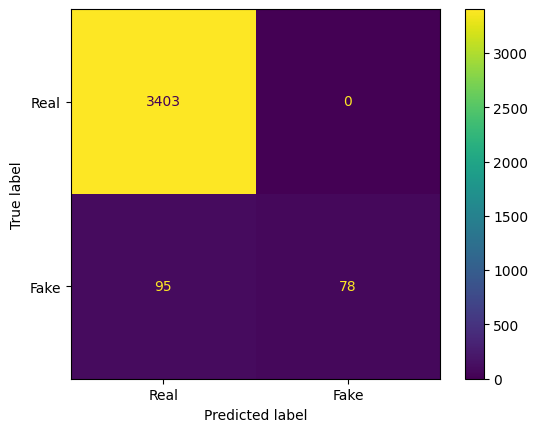

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()

In [11]:
balanced_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

balanced_predictions = balanced_lr.fit(
    X_train_tfidf,
    y_train
).predict(X_test_tfidf)

In [12]:
print("Accuracy :", accuracy_score(y_test, balanced_predictions))
print("Precision:", precision_score(y_test, balanced_predictions))
print("Recall   :", recall_score(y_test, balanced_predictions))
print("F1 Score :", f1_score(y_test, balanced_predictions))

print(classification_report(y_test, balanced_predictions))

Accuracy : 0.9773489932885906
Precision: 0.7110091743119266
Recall   : 0.8959537572254336
F1 Score : 0.7928388746803069
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.71      0.90      0.79       173

    accuracy                           0.98      3576
   macro avg       0.85      0.94      0.89      3576
weighted avg       0.98      0.98      0.98      3576



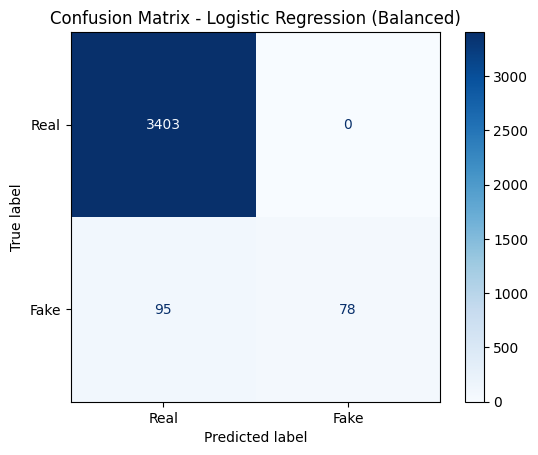

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression (Balanced)")
plt.show()

In [14]:
# Model 3: Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

In [15]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
nb_predictions = nb_model.predict(
    X_test_tfidf
)

In [17]:
print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

print(classification_report(y_test, nb_predictions))

Accuracy : 0.9644854586129754
Precision: 0.9107142857142857
Recall   : 0.2947976878612717
F1 Score : 0.44541484716157204
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.91      0.29      0.45       173

    accuracy                           0.96      3576
   macro avg       0.94      0.65      0.71      3576
weighted avg       0.96      0.96      0.96      3576



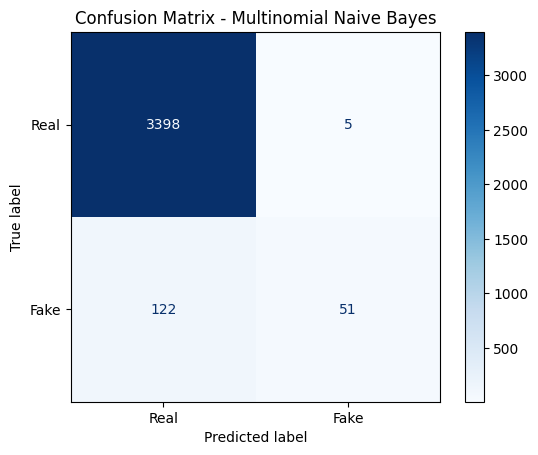

In [18]:
cm = confusion_matrix(y_test, nb_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

In [19]:
from sklearn.svm import LinearSVC

In [20]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [21]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [22]:
print("Accuracy :", accuracy_score(y_test, svm_predictions))
print("Precision:", precision_score(y_test, svm_predictions))
print("Recall   :", recall_score(y_test, svm_predictions))
print("F1 Score :", f1_score(y_test, svm_predictions))

print(classification_report(y_test, svm_predictions))

Accuracy : 0.9860178970917226
Precision: 0.984251968503937
Recall   : 0.7225433526011561
F1 Score : 0.8333333333333334
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.98      0.72      0.83       173

    accuracy                           0.99      3576
   macro avg       0.99      0.86      0.91      3576
weighted avg       0.99      0.99      0.98      3576



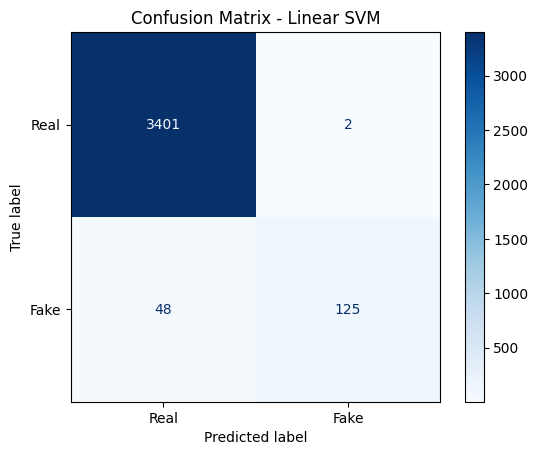

In [23]:
cm = confusion_matrix(y_test, svm_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [24]:
svm_balanced = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

svm_balanced.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [25]:
balanced_svm_predictions = svm_balanced.predict(
    X_test_tfidf
)

In [26]:
print("Accuracy :", accuracy_score(y_test, balanced_svm_predictions))
print("Precision:", precision_score(y_test, balanced_svm_predictions))
print("Recall   :", recall_score(y_test, balanced_svm_predictions))
print("F1 Score :", f1_score(y_test, balanced_svm_predictions))

print(classification_report(
    y_test,
    balanced_svm_predictions
))

Accuracy : 0.985178970917226
Precision: 0.8614457831325302
Recall   : 0.8265895953757225
F1 Score : 0.8436578171091446
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.86      0.83      0.84       173

    accuracy                           0.99      3576
   macro avg       0.93      0.91      0.92      3576
weighted avg       0.98      0.99      0.99      3576



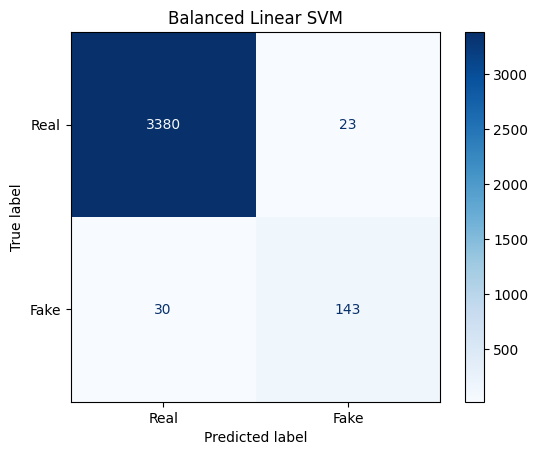

In [27]:
cm = confusion_matrix(
    y_test,
    balanced_svm_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Balanced Linear SVM")

plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [30]:
rf_model.fit(
    X_train_tfidf,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_predictions = rf_model.predict(
    X_test_tfidf
)

In [32]:
print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))

print(classification_report(
    y_test,
    rf_predictions
))

Accuracy : 0.9832214765100671
Precision: 1.0
Recall   : 0.653179190751445
F1 Score : 0.7902097902097902
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.65      0.79       173

    accuracy                           0.98      3576
   macro avg       0.99      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



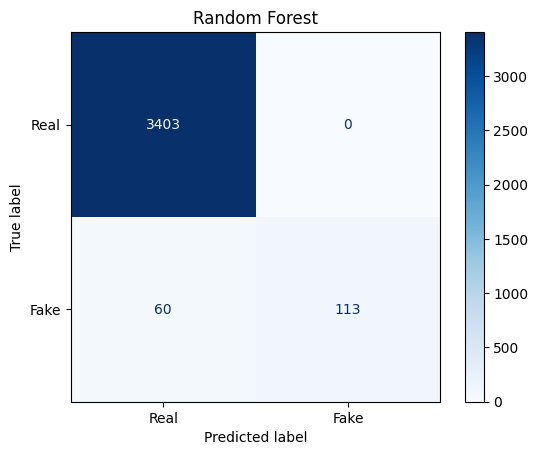

In [33]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest")

plt.show()

In [40]:
import joblib

joblib.dump(
    svm_balanced,
    "../trained_models/fake_job_detector.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [41]:
joblib.dump(
    vectorizer,
    "../trained_models/tfidf_vectorizer.pkl"
)

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [42]:
import os

os.listdir("../trained_models")

['fake_job_detector.pkl', 'tfidf_vectorizer.pkl']

In [43]:
import pandas as pd

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Balanced Linear SVM",
        "Random Forest"
    ],

    "Accuracy": [
        0.973434004474273,
        0.9773489932885906,
        0.9644854586129754,
        0.9860178970917226,
        0.985178970917226,
        0.9832214765100671
    ],

    "Precision": [
        1.0000000000000000,
        0.7110091743119266,
        0.9107142857142857,
        0.9842519685039370,
        0.8614457831325302,
        1.0000000000000000
    ],

    "Recall": [
        0.4508670520231214,
        0.8959537572254336,
        0.2947976878612717,
        0.7225433526011561,
        0.8265895953757225,
        0.6531791907514450
    ],

    "F1 Score": [
        0.6215139442231076,
        0.7928388746803069,
        0.4454148471615720,
        0.8333333333333334,
        0.8436578171091446,
        0.7902097902097902
    ]

})

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results.index = results.index + 1

results

,Model,Accuracy,Precision,Recall,F1 Score
1,Balanced Linear SVM,0.985179,0.861446,0.826590,0.843658
2,Linear SVM,0.986018,0.984252,0.722543,0.833333
3,Balanced Logistic Regression,0.977349,0.711009,0.895954,0.792839
4,Random Forest,0.983221,1.000000,0.653179,0.790210
5,Logistic Regression,0.973434,1.000000,0.450867,0.621514
6,Multinomial Naive Bayes,0.964485,0.910714,0.294798,0.445415


In [44]:
print("=" * 70)
print("FINAL MODEL SELECTED")
print("=" * 70)

print("Model       : Balanced Linear SVM")
print("Accuracy    : 98.52%")
print("Precision   : 86.14%")
print("Recall      : 82.66%")
print("F1 Score    : 84.37%")

print("\nReason:")
print("- Highest F1 Score among all evaluated models.")
print("- Excellent balance between Precision and Recall.")
print("- Well-suited for highly imbalanced text classification.")
print("- Maintains high Accuracy while detecting most fraudulent job postings.")
print("- Selected as the final deployment model.")

FINAL MODEL SELECTED
Model       : Balanced Linear SVM
Accuracy    : 98.52%
Precision   : 86.14%
Recall      : 82.66%
F1 Score    : 84.37%

Reason:
- Highest F1 Score among all evaluated models.
- Excellent balance between Precision and Recall.
- Well-suited for highly imbalanced text classification.
- Maintains high Accuracy while detecting most fraudulent job postings.
- Selected as the final deployment model.


# Calibrated Balanced Linear SVM

In [45]:
from sklearn.calibration import CalibratedClassifierCV

In [46]:
calibrated_svm = CalibratedClassifierCV(
    estimator=svm_balanced,
    method="sigmoid",
    cv=5
)

In [47]:
calibrated_svm.fit(
    X_train_tfidf,
    y_train
)

,estimator,LinearSVC(cla...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [48]:
calibrated_predictions = calibrated_svm.predict(
    X_test_tfidf
)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, calibrated_predictions))
print("Precision:", precision_score(y_test, calibrated_predictions))
print("Recall   :", recall_score(y_test, calibrated_predictions))
print("F1 Score :", f1_score(y_test, calibrated_predictions))

print()
print(classification_report(
    y_test,
    calibrated_predictions
))

Accuracy : 0.9865771812080537
Precision: 0.9496402877697842
Recall   : 0.7630057803468208
F1 Score : 0.8461538461538461

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.95      0.76      0.85       173

    accuracy                           0.99      3576
   macro avg       0.97      0.88      0.92      3576
weighted avg       0.99      0.99      0.99      3576



In [50]:
probabilities = calibrated_svm.predict_proba(
    X_test_tfidf[:5]
)

probabilities

array([[0.95047652, 0.04952348],
       [0.99240896, 0.00759104],
       [0.99760294, 0.00239706],
       [0.9988588 , 0.0011412 ],
       [0.99797666, 0.00202334]])

# Save Final Model

In [51]:
import joblib

joblib.dump(
    calibrated_svm,
    "../trained_models/fake_job_detector.pkl"
)

['../trained_models/fake_job_detector.pkl']

# Verify Saved Model

In [52]:
loaded_model = joblib.load(
    "../trained_models/fake_job_detector.pkl"
)

type(loaded_model)

sklearn.calibration.CalibratedClassifierCV